In [2]:
import xarray as xr
import numpy as np

In [1]:
import regionmask


In [4]:
basins = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50

<GeoAxesSubplot:>

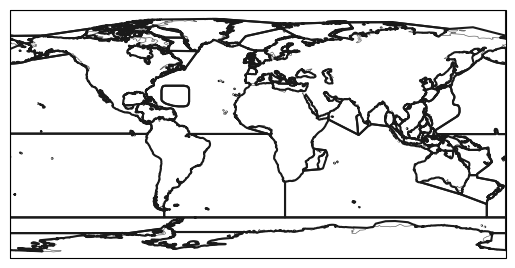

In [5]:
basins.plot(add_ocean=False, add_label=False)

In [6]:
from xmip.regionmask import merged_mask

In [7]:
vo_ds = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/vo/gn/latest/*.nc')

In [ ]:
vo = vo_ds['vo']
vo

<xarray.DataArray 'vo' (time: 1980, lev: 50, j: 300, i: 360)>
dask.array<concatenate, shape=(1980, 50, 300, 360), dtype=float32, chunksize=(120, 50, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
  * lev        (lev) float64 5.0 15.0 25.0 ... 5.166e+03 5.499e+03 5.831e+03
  * j          (j) int32 0 1 2 3 4 5 6 7 8 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    standard_name:  sea_water_y_velocity
    long_name:      Sea Water Y Velocity
    comment:        Prognostic y-ward velocity component resolved by the model.
    units:          m s-1
    cell_methods:   time: mean
    history:        2020-06-05T05:04:19Z altered by CMOR: replaced missing va...

In [9]:
vol = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/volcello/gn/latest/*.nc')['volcello']

In [16]:
vo = vo.drop(['latitude', 'longitude'])
vo

<xarray.DataArray 'vo' (time: 1980, lev: 50, j: 300, i: 360)>
dask.array<concatenate, shape=(1980, 50, 300, 360), dtype=float32, chunksize=(120, 50, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
  * lev      (lev) float64 5.0 15.0 25.0 35.0 ... 5.166e+03 5.499e+03 5.831e+03
  * j        (j) int32 0 1 2 3 4 5 6 7 8 ... 291 292 293 294 295 296 297 298 299
  * i        (i) int32 0 1 2 3 4 5 6 7 8 ... 351 352 353 354 355 356 357 358 359
Attributes:
    standard_name:  sea_water_y_velocity
    long_name:      Sea Water Y Velocity
    comment:        Prognostic y-ward velocity component resolved by the model.
    units:          m s-1
    cell_methods:   time: mean
    history:        2020-06-05T05:04:19Z altered by CMOR: replaced missing va...

In [18]:
vo = vo.rename(dict(j='lat', i='lon'))
vol = vol.rename(dict(j='lat', i='lon'))

In [19]:
mask = merged_mask(basins, vo)

KeyError: 'Ross Sea Eastern Basin'

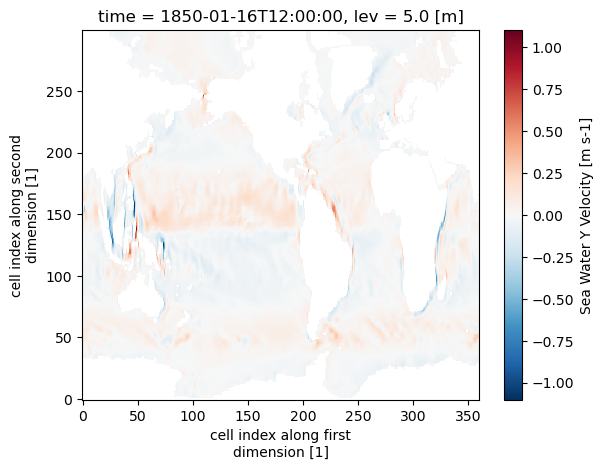

In [22]:
vo.isel(lev=0, time=0).plot()

In [32]:
mask = basins.mask_3D(vo.isel(lev=0, time=0))

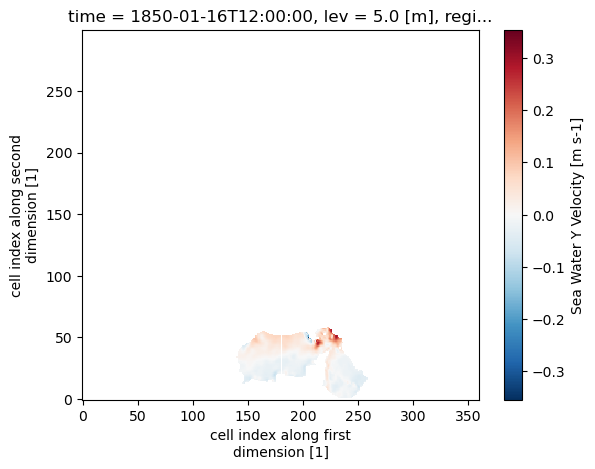

In [36]:

vo.isel(lev=0, time=0).where(mask.isel(region = [2])).plot()